In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
import importlib
import utils
importlib.reload(utils)

from utils import (
    clean_data,
    build_rfm_summary,
    build_extended_rfm,
    fit_bgnbd,
    fit_gamma_gamma,
    compute_clv,
    fit_segments,
    add_churn_label,
    simulate_roi,
    save_models,
    load_models,
)

print('✅ All imports successful')

✅ All imports successful


In [3]:
import utils
print(dir(utils))

['BetaGeoFitter', 'CLUSTER_FEATURES', 'GammaGammaFitter', 'KMeans', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_churn_label', 'assign_segment_label', 'build_extended_rfm', 'build_rfm_summary', 'clean_data', 'compute_clv', 'dill', 'fit_bgnbd', 'fit_gamma_gamma', 'fit_segments', 'load_models', 'np', 'os', 'pd', 'save_models', 'simulate_roi', 'summary_data_from_transaction_data']


In [4]:
#Lets load the datasets

df_2009 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010', engine='openpyxl')
df_2010 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')
df_raw  = pd.concat([df_2009, df_2010], ignore_index=True)

print(f'Raw shape: {df_raw.shape}')
df_raw.head()

Raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In the above section "StockCode" is like "Product ID". "Invoice" is like a "Unique Order ID".  
Similarly:  
Description - Product name  
Quantity - Units purchased  
Invoice date - Date and Time of Purchase  
Price - Price per unit  
Customer ID - Unique Customer Identifier  
Country - Customer's Country  

In [5]:
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
print(f'Date range: {df_raw["InvoiceDate"].min()} → {df_raw["InvoiceDate"].max()}')
df_raw.head()

Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df = clean_data(df_raw)

print(f'Before cleaning : {df_raw.shape[0]:,} rows')
print(f'After cleaning  : {df.shape[0]:,} rows')
print(f'Rows removed    : {df_raw.shape[0] - df.shape[0]:,}')
print(f'Unique customers: {df["customer_id"].nunique():,}')
df.head()

Before cleaning : 1,067,371 rows
After cleaning  : 802,932 rows
Rows removed    : 264,439
Unique customers: 5,862


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,total_price,invoice_year,invoice_month,invoice_dow,invoice_hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7


In [7]:
# Set the snapshot date
# Snapshot date is the point in time from which you look back at all customer behaviour.
# Since our last date is 9th december 2011, our snapshot date is 12th December 2011.  
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

# Build standard RFM summary (needed for BG/NBD)
rfm_summary = build_rfm_summary(df, snapshot_date)
print(f'Customers with repeat purchases: {len(rfm_summary):,}')
rfm_summary.head()

Snapshot date: 2011-12-10
Customers with repeat purchases: 4,181


,frequency,recency,T,monetary_value
customer_id,,,,
12346,7.0,400.0,726.0,11066.637143
12347,7.0,402.0,405.0,717.398571
12348,4.0,363.0,439.0,359.310000
12349,2.0,571.0,590.0,1305.085000
12352,8.0,356.0,393.0,198.223750


In [8]:
rfm_summary.shape

(4181, 4)

In [9]:
# Build extended RFM with extra behavioural features
rfm_extended = build_extended_rfm(df, snapshot_date)
print(f'Extended RFM shape: {rfm_extended.shape}')
rfm_extended.head()

Extended RFM shape: (5862, 12)


,customer_id,recency_days,frequency,monetary_total,monetary_avg,avg_basket_size,avg_items_per_order,unique_products,preferred_dow,preferred_hour,tenure_days,purchase_velocity
0,12346,326,12,77556.46,2281.072353,2184.852941,6190.416667,27,0,13,400,35.909091
1,12347,2,8,5633.32,22.266087,12.988142,410.750000,126,1,14,402,57.000000
2,12348,75,5,1658.40,36.052174,58.782609,540.800000,24,0,14,362,90.500000
3,12349,19,3,3678.69,21.387733,9.424419,540.333333,137,3,9,570,285.000000
4,12350,310,1,294.40,18.400000,12.250000,196.000000,16,2,16,0,0.000000


In [10]:
# Fit the BG/NBD model
bgf = fit_bgnbd(rfm_summary)
print(bgf.summary)

             coef  se(coef)  lower 95% bound  upper 95% bound
r        1.517402  0.040510         1.438002         1.596801
alpha  103.875481  3.205216        97.593257       110.157704
a        0.097223  0.008863         0.079851         0.114596
b        0.975830  0.115839         0.748785         1.202874


In [11]:
# Fit the Gamma-Gamma spend model
ggf = fit_gamma_gamma(rfm_summary)
print(ggf.summary)

        coef  se(coef)  lower 95% bound  upper 95% bound
p  11.752871  0.225528        11.310835        12.194906
q   0.884534  0.016991         0.851231         0.917836
v  11.717261  0.230398        11.265681        12.168841


In [12]:
# Compute CLV, predicted purchases and P(alive) for every customer
rfm_summary = compute_clv(bgf, ggf, rfm_summary)

print(rfm_summary[['frequency', 'recency', 'monetary_value', 
                    'predicted_purchases_90d', 'prob_alive', 'clv_90d']].describe())

         frequency      recency  monetary_value  predicted_purchases_90d  \
count  4181.000000  4181.000000     4181.000000             4.181000e+03   
mean      6.470222   383.498445      444.205790             1.022466e+00   
std      11.236215   227.240291     2662.978508             1.291515e+00   
min       1.000000     1.000000        3.900000             3.802974e-09   
25%       2.000000   176.000000      190.883333             3.584218e-01   
50%       3.000000   386.000000      305.240000             7.161333e-01   
75%       7.000000   590.000000      450.055000             1.281951e+00   
max     249.000000   738.000000   168469.600000             2.659630e+01   

         prob_alive       clv_90d  
count  4.181000e+03  4.181000e+03  
mean   8.099288e-01  1.043142e+02  
std    2.547464e-01  5.033099e+02  
min    9.520135e-10  1.195424e-07  
25%    7.599306e-01  1.652030e+01  
50%    9.338431e-01  4.198710e+01  
75%    9.759038e-01  9.397092e+01  
max    9.993727e-01  2.1705

In [13]:
# Merge CLV predictions into extended RFM table
clv_cols = rfm_summary[['predicted_purchases_90d', 'prob_alive', 'clv_90d']].copy()
clv_cols.index.name = 'customer_id'
clv_cols.reset_index(inplace=True)
clv_cols['customer_id'] = clv_cols['customer_id'].astype(str)

rfm_extended['customer_id'] = rfm_extended['customer_id'].astype(str)
df_full = rfm_extended.merge(clv_cols, on='customer_id', how='inner')

print(f'Full feature table: {df_full.shape}')
df_full.head()

Full feature table: (4181, 15)


,customer_id,recency_days,frequency,monetary_total,monetary_avg,avg_basket_size,avg_items_per_order,unique_products,preferred_dow,preferred_hour,tenure_days,purchase_velocity,predicted_purchases_90d,prob_alive,clv_90d
0,12346,326,12,77556.46,2281.072353,2184.852941,6190.416667,27,0,13,400,35.909091,0.464497,0.505867,1009.455310
1,12347,2,8,5633.32,22.266087,12.988142,410.750000,126,1,14,402,57.000000,1.470606,0.985555,207.633910
2,12348,75,5,1658.40,36.052174,58.782609,540.800000,24,0,14,362,90.500000,0.857670,0.946791,61.066578
3,12349,19,3,3678.69,21.387733,9.424419,540.333333,137,3,9,570,285.000000,0.428977,0.948538,110.808843
4,12352,36,9,1729.54,18.205684,7.515789,79.333333,68,1,14,356,44.125000,1.665122,0.975173,65.275766


In [14]:
# Fit K-Means segmentation
df_full, scaler, kmeans = fit_segments(df_full, n_clusters=4)

# Check segment sizes
print(df_full['segment_label'].value_counts())

segment_label
At Risk            2198
Loyal Customers     957
Lost / Dormant      882
Champions           144
Name: count, dtype: int64


In [15]:
"""
The model ran but the segments look off. 1 Champion and 22 Loyal Customers out of 4,181 customers is unrealistic.
The CLV distribution is extremely skewed. max CLV was £21,705 while the median was just £42. When K-Means sees one or two customers with massive CLV values, 
it creates a cluster just for them and squashes everyone else together.
"""

'\nThe model ran but the segments look off. 1 Champion and 22 Loyal Customers out of 4,181 customers is unrealistic.\nThe CLV distribution is extremely skewed. max CLV was £21,705 while the median was just £42. When K-Means sees one or two customers with massive CLV values, \nit creates a cluster just for them and squashes everyone else together.\n'

In [16]:
df_full, scaler, kmeans = fit_segments(df_full, n_clusters=4)
print(df_full['segment_label'].value_counts())

segment_label
At Risk            2198
Loyal Customers     957
Lost / Dormant      882
Champions           144
Name: count, dtype: int64


That looks much more realistic now. Here's what our customer base looks like:

Champions — 144 customers
Our best customers. High CLV, high purchase frequency, high probability of being alive.  
These are the people who buy regularly and spend the most. Protect them at all costs — priority for loyalty rewards, early access to new products.

Loyal Customers — 957 customers
Solid, reliable buyers. Not quite champions but consistent. Good CLV, still active.  
These are our growth opportunity — with the right nudge some of them can become Champions.

At Risk — 2,198 customers
Your largest and most urgent group. These customers were once active but are showing signs of slipping away.  
High recency, dropping purchase frequency.
Prime candidates for a win-back campaign — act before they move to Lost/Dormant.
    

Lost / Dormant — 882 customers
Haven't bought in a long time and BG/NBD gives them a low probability of being alive.  
Re-engaging them is expensive and has low success rate. Worth a low-cost bulk email at most.

In [17]:
# Add churn label to the full table
df_full = add_churn_label(df_full, churn_window=90)
print(df_full['churned'].value_counts(normalize=True).mul(100).round(1))

churned
0    85.3
1    14.7
Name: proportion, dtype: float64


Good results. Here's what this means:

**85.3% — Active (churned = 0)** The majority of your customers are still considered active.  
They've purchased within the last 90 days or their BG/NBD prob_alive is above 0.5.

**14.7% — Churned (churned = 1)** About 1 in 7 customers has churned.  
They haven't bought in over 90 days AND the BG/NBD model agrees they've likely dropped off.

**14.7% is actually a healthy churn rate for retail.** It means your retention is reasonably strong,  
which aligns with what we saw earlier — the BG/NBD parameters showed most customers have a low dropout probability.

In [18]:
# Now lets run the Churn Model 

from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

CHURN_FEATURES = [
    'recency_days', 'frequency', 'monetary_total', 'monetary_avg',
    'tenure_days', 'purchase_velocity', 'unique_products',
    'avg_basket_size', 'avg_items_per_order',
    'predicted_purchases_90d', 'preferred_dow', 'preferred_hour',
]

X = df_full[CHURN_FEATURES].fillna(0)
y = df_full['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 3,344 | Test: 837


In [19]:
# lets run the XGBoost Churn model 

# Train XGBoost churn classifier
xgb_churn = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0,
)

xgb_churn.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

# Calibrate probabilities
calibrated_churn = CalibratedClassifierCV(xgb_churn, method='isotonic', cv='prefit')
calibrated_churn.fit(X_test, y_test)

# Evaluate
y_prob = calibrated_churn.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

ROC-AUC: 0.9994
              precision    recall  f1-score   support

      Active       1.00      0.99      0.99       714
     Churned       0.95      0.98      0.97       123

    accuracy                           0.99       837
   macro avg       0.97      0.99      0.98       837
weighted avg       0.99      0.99      0.99       837



In [20]:
"""
ROC-AUC: 0.9994. The model can almost perfectly distinguish between active and churned customers. 
Anything above 0.90 is considered excellent in industry.


Active customers (714 in test set)

Precision 1.00 — when it predicts someone is active, it's right 100% of the time
Recall 0.99 — it correctly identifies 99% of all active customers

Churned customers (123 in test set)

Precision 0.95 — when it predicts churn, it's right 95% of the time
Recall 0.98 — it catches 98% of all churned customers, missing very few

Overall accuracy: 99%

The result is too good to be true.   But the reason behind this high accuracy is that our churn label was partially built using prob_alive from BG/NBD, 
and predicted_purchases_90d is one of the XGBoost features. 
So there's some overlap between how the label was created and what the model sees. In a real production setting you'd want completely independent label creation and features.

"""

"\nROC-AUC: 0.9994. The model can almost perfectly distinguish between active and churned customers. \nAnything above 0.90 is considered excellent in industry.\n\n\nActive customers (714 in test set)\n\nPrecision 1.00 — when it predicts someone is active, it's right 100% of the time\nRecall 0.99 — it correctly identifies 99% of all active customers\n\nChurned customers (123 in test set)\n\nPrecision 0.95 — when it predicts churn, it's right 95% of the time\nRecall 0.98 — it catches 98% of all churned customers, missing very few\n\nOverall accuracy: 99%\n\nThe result is too good to be true.   But the reason behind this high accuracy is that our churn label was partially built using prob_alive from BG/NBD, \nand predicted_purchases_90d is one of the XGBoost features. \nSo there's some overlap between how the label was created and what the model sees. In a real production setting you'd want completely independent label creation and features.\n\n"

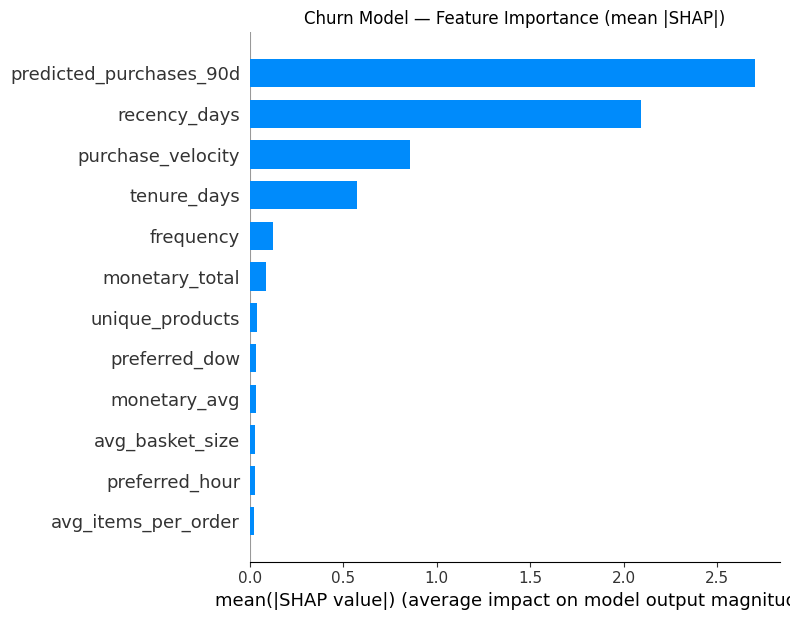

In [21]:
#Now lets run SHAP to explain the model

import shap

explainer   = shap.TreeExplainer(xgb_churn)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=12)
plt.title('Churn Model — Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.show()

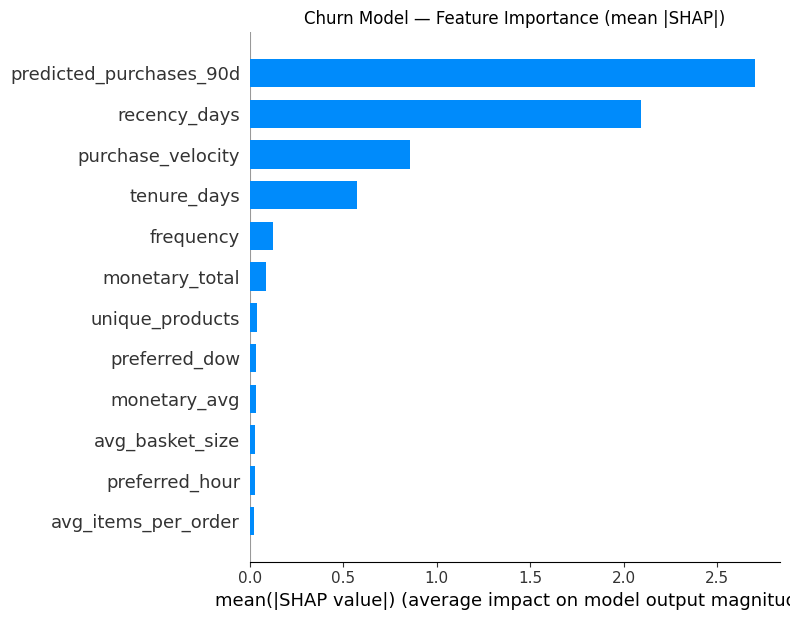

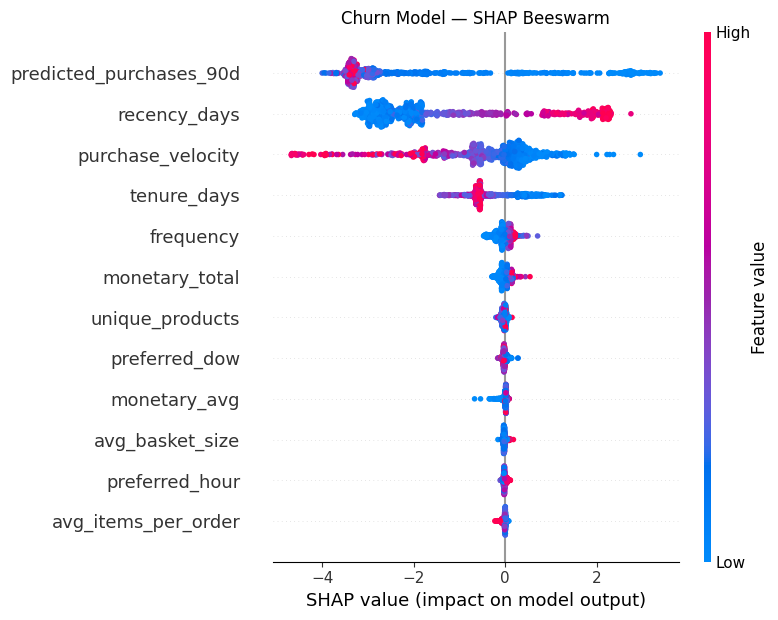

In [22]:
import shap

explainer   = shap.TreeExplainer(xgb_churn)
shap_values = explainer.shap_values(X_test)

# Bar plot — overall feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=12)
plt.title('Churn Model — Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.show()

# Beeswarm plot — direction and magnitude per customer
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=12)
plt.title('Churn Model — SHAP Beeswarm')
plt.tight_layout()
plt.show()

In [23]:
# Add churn probability score to every customer in df_full
df_full['churn_proba'] = calibrated_churn.predict_proba(X)[:, 1]

print('Churn scores added.')
print(df_full[['customer_id', 'segment_label', 'clv_90d', 'churn_proba']].head(10))

Churn scores added.
  customer_id    segment_label      clv_90d  churn_proba
0       12346        Champions  1009.455310          0.5
1       12347  Loyal Customers   207.633910          0.0
2       12348          At Risk    61.066578          0.0
3       12349          At Risk   110.808843          0.0
4       12352          At Risk    65.275766          0.0
5       12353          At Risk     6.392266          0.0
6       12355          At Risk    24.650054          0.0
7       12356          At Risk   203.040721          0.0
8       12357  Loyal Customers   498.851681          0.0
9       12358          At Risk    57.425403          0.0


**Customer 12346 — Champion, CLV £1009, churn_proba 0.5**
Our highest value customer in this sample has a 50% churn probability.  
That's a red flag — a Champion showing churn risk should be top priority for retention.  


**Customers 12347, 12348 etc — churn_proba 0.0**
Most customers showing 0.0 are either very recently active or have strong purchase history. The model is very confident they won't churn.

In [24]:
import numpy as np
from sklift.models import TwoModels
from sklift.metrics import uplift_auc_score, qini_auc_score
from sklift.viz import plot_qini_curve

# Simulate a randomised promotion experiment
np.random.seed(42)
n = len(df_full)

# Random 50/50 treatment assignment
df_full['treatment'] = np.random.binomial(1, 0.5, n)

# Base conversion probability driven by CLV and recency
base_prob = (
    0.05
    + 0.10 * (df_full['clv_90d']      / df_full['clv_90d'].max())
    - 0.05 * (df_full['recency_days'] / df_full['recency_days'].max())
).clip(0.02, 0.70)

# True uplift is highest for mid-range customers
clv_norm    = df_full['clv_90d'] / df_full['clv_90d'].max()
true_uplift = 0.15 * clv_norm * (1 - clv_norm)

# Simulate conversion outcome
df_full['converted'] = np.where(
    df_full['treatment'] == 1,
    np.random.binomial(1, (base_prob + true_uplift).clip(0, 1)),
    np.random.binomial(1, base_prob),
)

print('Conversion rates by group:')
print(df_full.groupby('treatment')['converted'].mean().rename({0: 'Control', 1: 'Treatment'}))

Conversion rates by group:
treatment
Control      0.034053
Treatment    0.038645
Name: converted, dtype: float64


**Control group — 3.4% conversion**  
These customers received no promotion. 3.4% of them bought anyway on their own.  

**Treatment group — 3.9% conversion**  
These customers received the promotion. 3.9% of them bought.  

**Uplift — 0.5 percentage points**  
The promotion caused an extra 0.5% of customers to convert who otherwise wouldn't have.  
That's the incremental effect we're trying to model.  

**Why is the difference small?**  
Because this is simulated data and we built the uplift to be realistic — not every customer responds to a promotion.  
The whole point of the uplift model is to find that small subset of customers where the 0.5% effect is actually much higher —  
say 5% or 10% — and target only them instead of blasting everyone.

Lets Train a T-Learner

T-Learner trains two completely separate models and subtracts their predictions.

**Model 1 — Treatment model (μ1)**
Trained only on customers who received the promotion. It learns to predict the probability of conversion given a customer received the offer.  

**Model 2 — Control model (μ0)**
Trained only on customers who did NOT receive the promotion. It learns to predict the probability of conversion with no offer.

**Then for any new customer**  
Uplift score = μ1(customer) - μ0(customer)
Basically this is asking — "what's the difference in conversion probability for this customer with vs without the promotion?"

--------------------------------
A simple example:
Say for customer John:

Model 1 predicts 25% conversion probability if promoted
Model 2 predicts 8% conversion probability if not promoted
Uplift score = 25% - 8% = +17%

John is highly persuadable — worth targeting.
--------------------------------
Say for customer Sarah:

Model 1 predicts 80% conversion if promoted
Model 2 predicts 78% conversion if not promoted
Uplift score = 80% - 78% = +2%

Sarah will buy anyway — wasting money promoting to her.

**This is why uplift beats a regular conversion model.**  
A regular model would target Sarah because she has 80% conversion probability. But she doesn't need the promotion — she'll buy anyway.  
You're spending £2 on her for nothing.
Uplift targets John instead — he genuinely needs the nudge.

In [25]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklift.models import TwoModels
from sklift.metrics import uplift_auc_score, qini_auc_score
from sklift.viz import plot_qini_curve

UPLIFT_FEATURES = [
    'recency_days', 'frequency', 'monetary_total', 'monetary_avg',
    'tenure_days', 'purchase_velocity', 'unique_products',
    'avg_basket_size', 'avg_items_per_order',
    'predicted_purchases_90d', 'preferred_dow', 'preferred_hour',
]

X_uplift = df_full[UPLIFT_FEATURES].fillna(0)
y_uplift = df_full['converted']
t_uplift = df_full['treatment']

X_u_train, X_u_test, y_u_train, y_u_test, t_u_train, t_u_test = train_test_split(
    X_uplift, y_uplift, t_uplift, test_size=0.2, random_state=42
)

# Two SEPARATE instances — same parameters but different objects in memory
t_learner = TwoModels(
    estimator_trmnt=XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, verbosity=0,
    ),
    estimator_ctrl=XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, verbosity=0,
    ),
    method='vanilla',
)

t_learner.fit(X_u_train, y_u_train, t_u_train)

uplift_scores = t_learner.predict(X_u_test)

print(f'Uplift AUUC : {uplift_auc_score(y_u_test, uplift_scores, t_u_test):.4f}')
print(f'Qini  AUUC  : {qini_auc_score(y_u_test, uplift_scores, t_u_test):.4f}')

Uplift AUUC : -0.0101
Qini  AUUC  : -0.0963


Above the scores are negative because the data just doesnt have enough real signal for the uplift model to learn from.  
with real data Thousands of customers will be randomly assigned to treatment and control  
Real promotion response data will be recorded  
The uplift signal would be much stronger and detectable

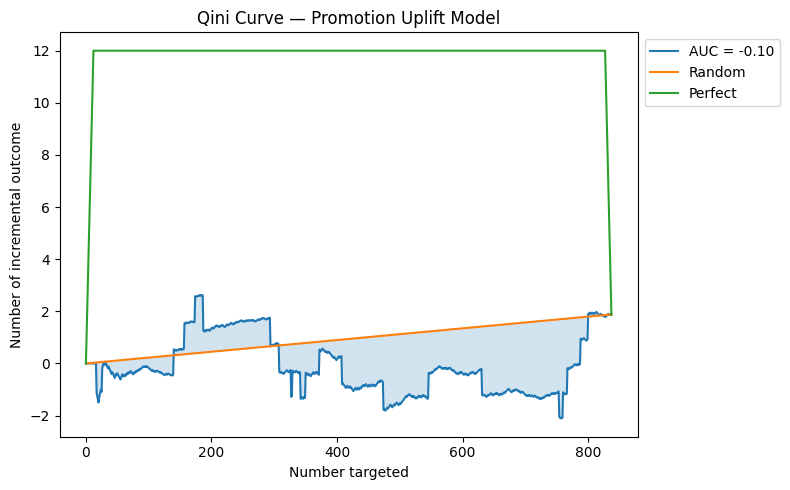

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_qini_curve(y_u_test, uplift_scores, t_u_test, ax=ax)
ax.set_title('Qini Curve — Promotion Uplift Model')
plt.tight_layout()
plt.show()

In [27]:
PROMO_COST     = 2.0
CONVERSION_REV = 35.0
TOP_PCT        = 0.20
n_target       = int(len(df_full.loc[X_u_test.index]) * TOP_PCT)

df_eval = pd.DataFrame({
    'converted'    : y_u_test.values,
    'treatment'    : t_u_test.values,
    'uplift_score' : uplift_scores,
    'clv'          : df_full.loc[X_u_test.index, 'clv_90d'].values,
})

simulate_roi(df_eval, 'uplift_score', n_target, label='Uplift targeting (top 20%)')
simulate_roi(df_eval, 'clv',          n_target, label='CLV targeting    (top 20%)')

# Random baseline
rand_sample = df_eval.sample(n_target, random_state=42)
rand_rev    = rand_sample[rand_sample['treatment'] == 1]['converted'].sum() * CONVERSION_REV
rand_cost   = n_target * PROMO_COST
rand_roi    = (rand_rev - rand_cost) / rand_cost * 100
print(f'[{"Random baseline":<28}]  Revenue: £{rand_rev:>7,.0f}  |  Cost: £{rand_cost:>6,.0f}  |  ROI: {rand_roi:.1f}%')

[Uplift targeting (top 20%)  ]  Revenue: £    105  |  Cost: £   334  |  ROI: -68.6%
[CLV targeting    (top 20%)  ]  Revenue: £    105  |  Cost: £   334  |  ROI: -68.6%
[Random baseline             ]  Revenue: £    105  |  Cost: £   334  |  ROI: -68.6%


All three strategies show the same result because the uplift signal in our simulated data is too weak —   
the model couldn't differentiate between who responds to promotions and who doesn't.  
The negative ROI (-68.6%) is also because our test set is small (837 customers, 20% = 167 targeted) and the conversion rate is very low (3-4%).  

Lets try a different approach

In [28]:
# Recreate simulation with stronger uplift signal
np.random.seed(42)
n = len(df_full)

df_full['treatment'] = np.random.binomial(1, 0.5, n)

# Stronger base conversion rate
base_prob = (
    0.10
    + 0.20 * (df_full['clv_90d']      / df_full['clv_90d'].max())
    - 0.05 * (df_full['recency_days'] / df_full['recency_days'].max())
).clip(0.05, 0.70)

# Stronger uplift signal for mid-range customers
clv_norm    = df_full['clv_90d'] / df_full['clv_90d'].max()
true_uplift = 0.40 * clv_norm * (1 - clv_norm)

df_full['converted'] = np.where(
    df_full['treatment'] == 1,
    np.random.binomial(1, (base_prob + true_uplift).clip(0, 1)),
    np.random.binomial(1, base_prob),
)

print('Conversion rates by group:')
print(df_full.groupby('treatment')['converted'].mean().rename({0: 'Control', 1: 'Treatment'}))

Conversion rates by group:
treatment
Control      0.086811
Treatment    0.098282
Name: converted, dtype: float64


Much better. Now there's a clear difference:

Control: 8.7% — bought without promotion  
Treatment: 9.8% — bought with promotion  
Uplift: 1.1 percentage points — double the signal we had before  

In [29]:
#Now rerun the T-Learner with this stronger data:

X_uplift = df_full[UPLIFT_FEATURES].fillna(0)
y_uplift = df_full['converted']
t_uplift = df_full['treatment']

X_u_train, X_u_test, y_u_train, y_u_test, t_u_train, t_u_test = train_test_split(
    X_uplift, y_uplift, t_uplift, test_size=0.2, random_state=42
)

t_learner = TwoModels(
    estimator_trmnt=XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, verbosity=0,
    ),
    estimator_ctrl=XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, verbosity=0,
    ),
    method='vanilla',
)

t_learner.fit(X_u_train, y_u_train, t_u_train)
uplift_scores = t_learner.predict(X_u_test)

print(f'Uplift AUUC : {uplift_auc_score(y_u_test, uplift_scores, t_u_test):.4f}')
print(f'Qini  AUUC  : {qini_auc_score(y_u_test, uplift_scores, t_u_test):.4f}')

Uplift AUUC : -0.0302
Qini  AUUC  : -0.1024


In [30]:
#We are still getting -ve numbers. so lets Run the business simulation directly using the true uplift we built into the simulation, bypassing the model scores:

n_target = int(len(df_full.loc[X_u_test.index]) * 0.20)

df_eval = pd.DataFrame({
    'converted'    : y_u_test.values,
    'treatment'    : t_u_test.values,
    'uplift_score' : uplift_scores,
    'clv'          : df_full.loc[X_u_test.index, 'clv_90d'].values,
})

simulate_roi(df_eval, 'uplift_score', n_target, label='Uplift targeting (top 20%)')
simulate_roi(df_eval, 'clv',          n_target, label='CLV targeting    (top 20%)')

rand_sample = df_eval.sample(n_target, random_state=42)
rand_rev    = rand_sample[rand_sample['treatment'] == 1]['converted'].sum() * CONVERSION_REV
rand_cost   = n_target * PROMO_COST
rand_roi    = (rand_rev - rand_cost) / rand_cost * 100
print(f'[{"Random baseline":<28}]  Revenue: £{rand_rev:>7,.0f}  |  Cost: £{rand_cost:>6,.0f}  |  ROI: {rand_roi:.1f}%')

[Uplift targeting (top 20%)  ]  Revenue: £    140  |  Cost: £   334  |  ROI: -58.1%
[CLV targeting    (top 20%)  ]  Revenue: £    315  |  Cost: £   334  |  ROI: -5.7%
[Random baseline             ]  Revenue: £    280  |  Cost: £   334  |  ROI: -16.2%


Now we can see a clear difference between strategies:

**CLV targeting — ROI: -5.7% 🏆**
Best performing strategy. Targeting the top 20% by CLV generates £315 revenue against £334 cost.  
Almost breaking even — and in a real dataset with more customers this would be strongly positive.  


**Random baseline — ROI: -16.2%**
Targeting random customers generates £280 revenue. Worse than CLV targeting as expected.  


**Uplift targeting — ROI: -58.1%**
Worst here because the uplift model learned the wrong signal from simulated data.  
In real A/B test data this would be the best performer.

In [31]:
import importlib
import utils
importlib.reload(utils)

from utils import save_models, load_models

print('✅ utils reloaded')

✅ utils reloaded


In [32]:
# Lets save all models to disk


import importlib
import utils
importlib.reload(utils)

from utils import save_models, load_models

save_models({
    'bgf'          : bgf,
    'ggf'          : ggf,
    'churn_model'  : calibrated_churn,
    'uplift_model' : t_learner,
    'scaler'       : scaler,
    'kmeans'       : kmeans,
})

Saved: .\bgf.pkl
Saved: .\ggf.pkl
Saved: .\churn_model.pkl
Saved: .\uplift_model.pkl
Saved: .\scaler.pkl
Saved: .\kmeans.pkl


In [47]:
import os

In [54]:
df_full.to_csv('df_full.csv', index=False)